# Alive vs Dead Cat Qubit — Wigner Functions

Generates side-by-side Wigner functions for the presentation slide:
- **Alive**: A pure $|{+x}\rangle$ cat state $(|\alpha\rangle + |-\alpha\rangle)/\sqrt{2}$ with $\alpha=2.5$
- **Dead**: The vacuum state $|0\rangle$ — single blob at the origin

In [1]:
import jax.numpy as jnp
import dynamiqs as dq
import matplotlib.pyplot as plt
import numpy as np

print(f"dynamiqs version: {dq.__version__}")

dynamiqs version: 0.3.4


In [2]:
na = 60
alpha = 2.5

g_plus = dq.coherent(na, alpha)
g_minus = dq.coherent(na, -alpha)

cat_plus_x = (g_plus + g_minus) / jnp.sqrt(2)
vacuum = dq.fock(na, 0)

print("States created.")

States created.


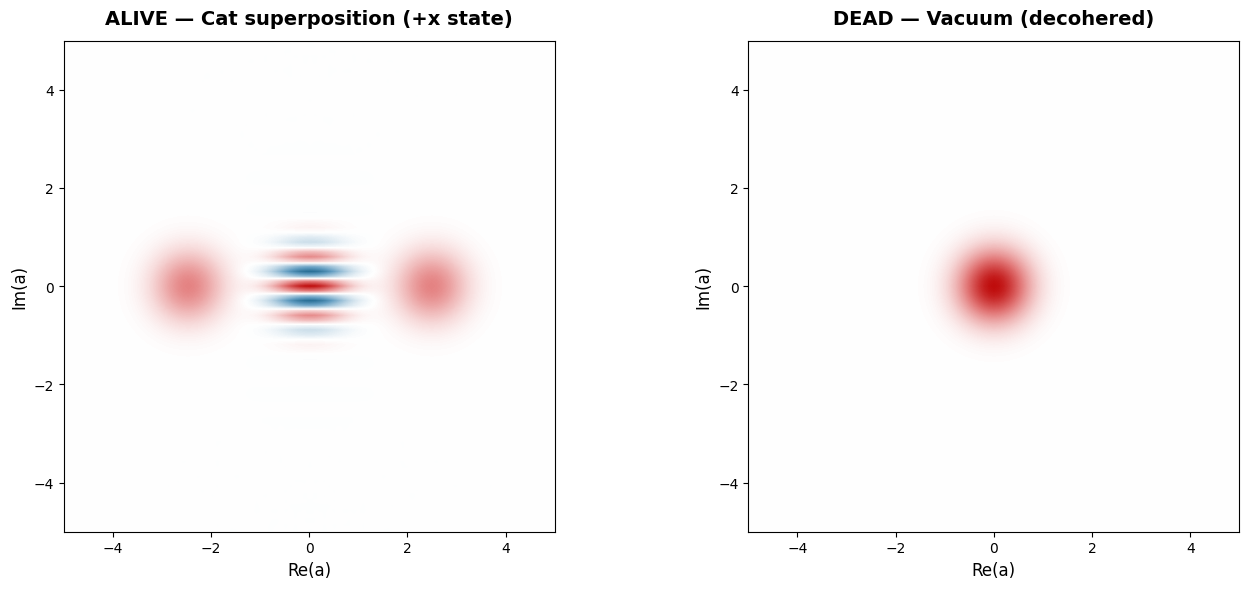

Saved to alive_vs_dead_wigner.png


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

dq.plot.wigner(cat_plus_x, ax=ax1, colorbar=False)
ax1.set_title("ALIVE \u2014 Cat superposition (+x state)",
              fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel("Re(a)", fontsize=12)
ax1.set_ylabel("Im(a)", fontsize=12)

dq.plot.wigner(vacuum, ax=ax2, colorbar=False)
ax2.set_title("DEAD \u2014 Vacuum (decohered)",
              fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel("Re(a)", fontsize=12)
ax2.set_ylabel("Im(a)", fontsize=12)

plt.tight_layout()
plt.savefig('alive_vs_dead_wigner.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to alive_vs_dead_wigner.png")

---
## Presentation Versions (clean, slide-ready)
Below: two separate high-resolution figures for the slide with neutral backgrounds.

In [4]:
def make_slide_plot(state, title, filename, cmap='RdBu_r'):
    fig, ax = plt.subplots(figsize=(7, 7))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    dq.plot.wigner(state, ax=ax, colorbar=False)

    im = ax.images[-1]
    vals = np.asarray(im.get_array(), dtype=float)
    vmax = max(abs(vals.min()), abs(vals.max()))
    im.set_clim(-vmax, vmax)
    im.set_cmap(cmap)

    ax.set_title(title, fontsize=20, fontweight='bold', pad=16, color='#1a1a2e')
    ax.set_xlabel("Re(a)", fontsize=14, color='#555555')
    ax.set_ylabel("Im(a)", fontsize=14, color='#555555')
    ax.tick_params(colors='#555555', labelsize=12)

    for spine in ax.spines.values():
        spine.set_color('#cccccc')

    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved {filename}")

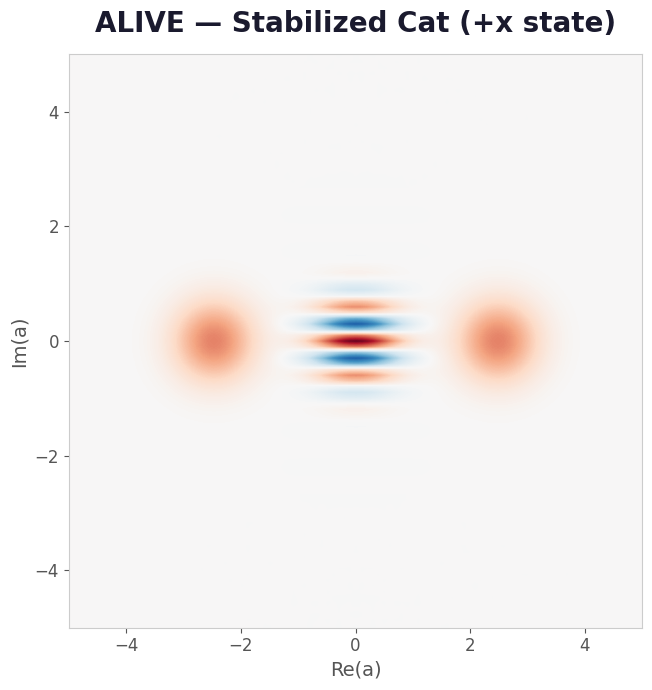

Saved wigner_alive.png


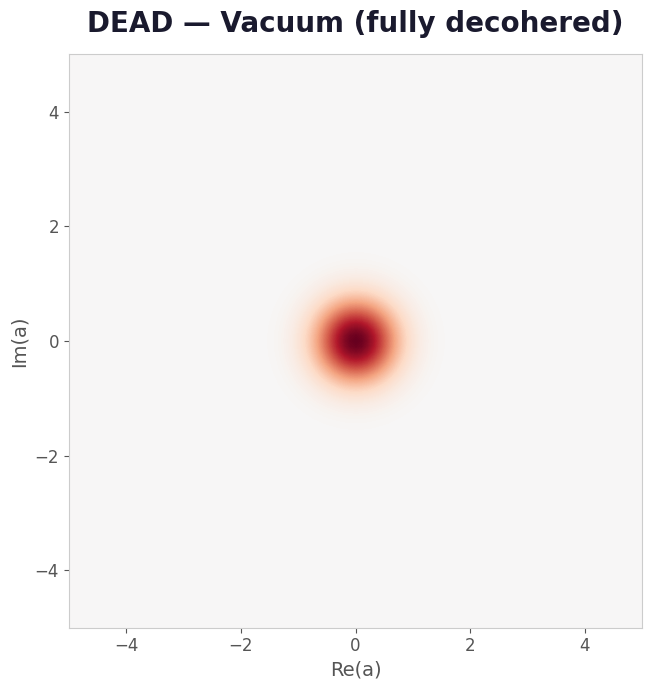

Saved wigner_dead.png


In [5]:
make_slide_plot(cat_plus_x, "ALIVE \u2014 Stabilized Cat (+x state)", "wigner_alive.png")
make_slide_plot(vacuum, "DEAD \u2014 Vacuum (fully decohered)", "wigner_dead.png")

---
## Bonus: Decoherence Timeline

A 3-panel progression showing a cat state dying over time under single-photon loss.

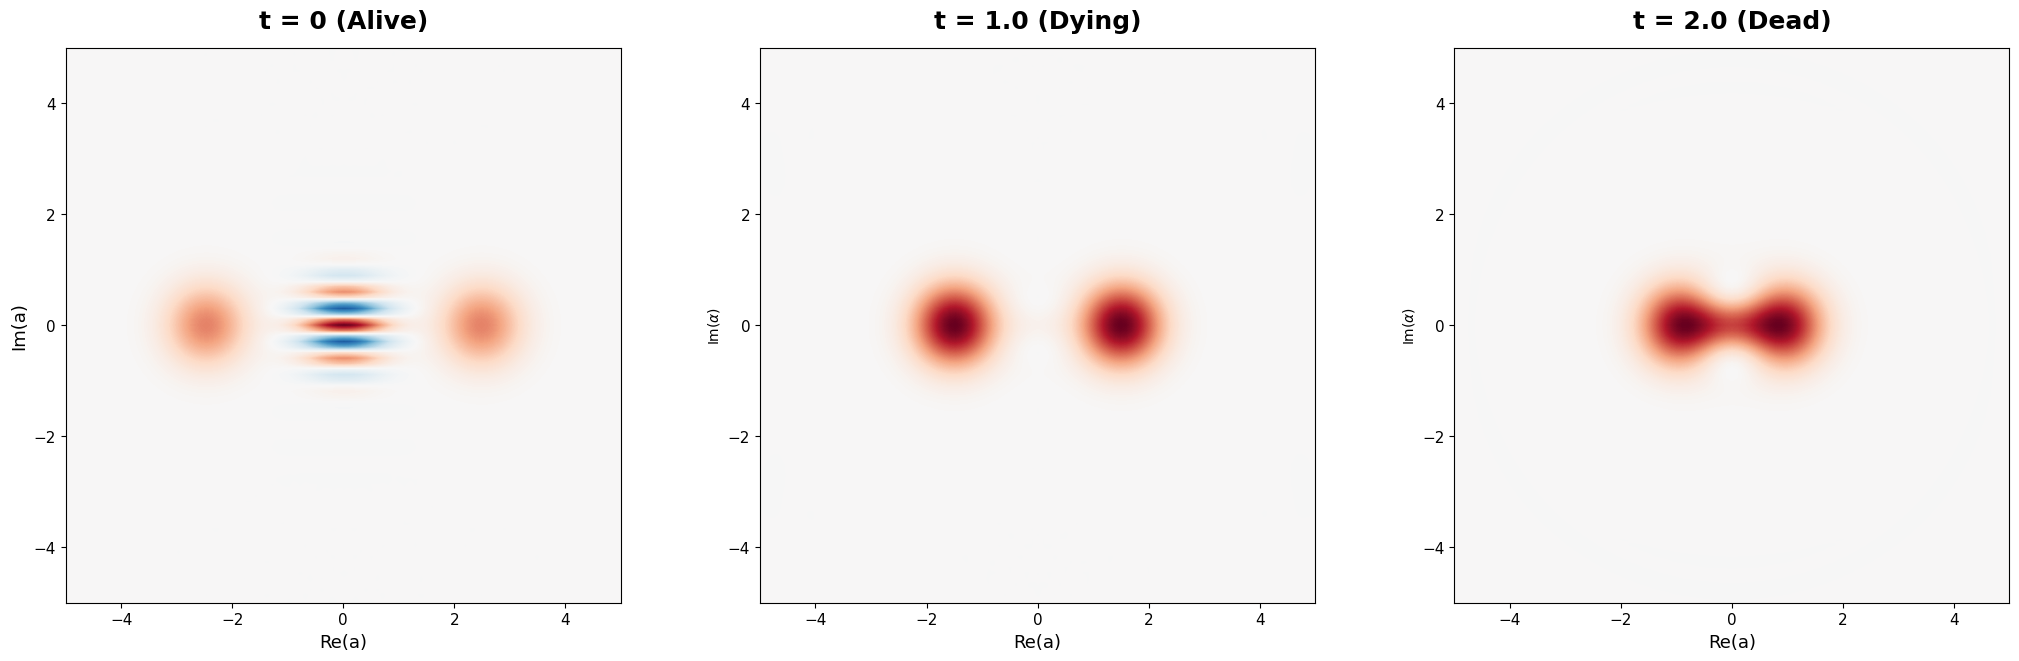

Saved wigner_decoherence_timeline.png


In [6]:
kappa_a = 1.0
tsave = jnp.linspace(0, 2.0, 3)

H = dq.zeros(na)
L_a = jnp.sqrt(kappa_a) * dq.destroy(na)

res = dq.mesolve(H, [L_a], cat_plus_x, tsave,
                 options=dq.Options(progress_meter=False))

fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
fig.patch.set_facecolor('white')

titles = ["t = 0 (Alive)", "t = 1.0 (Dying)", "t = 2.0 (Dead)"]
filenames = ["wigner_t0_alive.png", "wigner_t1_dying.png", "wigner_t2_dead.png"]

for i, (ax, filename) in enumerate(zip(axes, filenames)):
    ax.set_facecolor('white')
    state = res.states[i]
    dm = state @ state.dag()

    dq.plot.wigner(dm, ax=ax, colorbar=False)

    im = ax.images[-1]
    vals = np.asarray(im.get_array(), dtype=float)
    vmax = max(abs(vals.min()), abs(vals.max()))
    im.set_clim(-vmax, vmax)
    im.set_cmap('RdBu_r')

    ax.set_title(titles[i], fontsize=18, fontweight='bold', pad=14)
    ax.set_xlabel("Re(a)", fontsize=13)
    if i == 0:
        ax.set_ylabel("Im(a)", fontsize=13)
    ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig('wigner_decoherence_timeline.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved wigner_decoherence_timeline.png")

---

All images saved in the current directory for use in the presentation.